In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import sklearn 
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import plot_tree

### Basic Wrangling

In [9]:
#read in data
df = pd.read_csv('/Users/raenentraver-fallick/Documents/Spring26_Apps/patient_churn_dataset.csv')
df.head()

,Patient_ID,Age,Gender,Tenure_Months,Visits_Last_Year,Chronic_Disease,Insurance_Type,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments,Churn
0,1,56,Female,2,3,No,Government,2.5,12252.96,9,1
1,2,69,Male,10,3,Yes,Government,2.6,25862.01,4,0
2,3,46,Female,56,10,No,NaN,2.8,5659.13,4,0
3,4,32,Male,30,4,Yes,Government,4.1,19533.31,5,0
4,5,60,Male,50,19,No,Private,4.6,24639.52,5,0


In [10]:
#train test split 

X = df.drop(columns=['Churn', 'Patient_ID'], axis = 1)
y = df['Churn']

train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Exploratory Data Analysis

In [11]:
for i in X.columns.tolist():
    print(X[i].value_counts())

Age
79    18
50    16
77    16
41    14
52    14
      ..
73     4
51     4
30     3
60     2
27     1
Name: count, Length: 62, dtype: int64
Gender
Female    250
Male      250
Name: count, dtype: int64
Tenure_Months
51    17
47    16
26    14
5     14
33    13
6     13
56    12
30    12
14    12
37    12
2     11
15    11
4     11
38    11
10    11
34    11
17    11
45    11
11    11
55    11
1     10
40    10
31     9
59     9
57     9
3      9
8      9
49     9
22     9
54     8
25     8
21     8
35     7
23     7
24     7
13     7
27     7
39     7
29     7
50     6
36     6
20     6
44     6
52     6
9      6
53     6
18     6
28     6
12     5
19     5
42     5
32     5
48     5
43     5
41     5
58     3
46     3
16     2
7      2
Name: count, dtype: int64
Visits_Last_Year
16    34
7     31
1     30
12    29
4     29
10    27
2     26
17    26
6     26
8     25
18    25
9     25
11    23
13    23
14    23
3     22
0     20
5     20
19    19
15    17
Name: count, dtype: int64
Chro

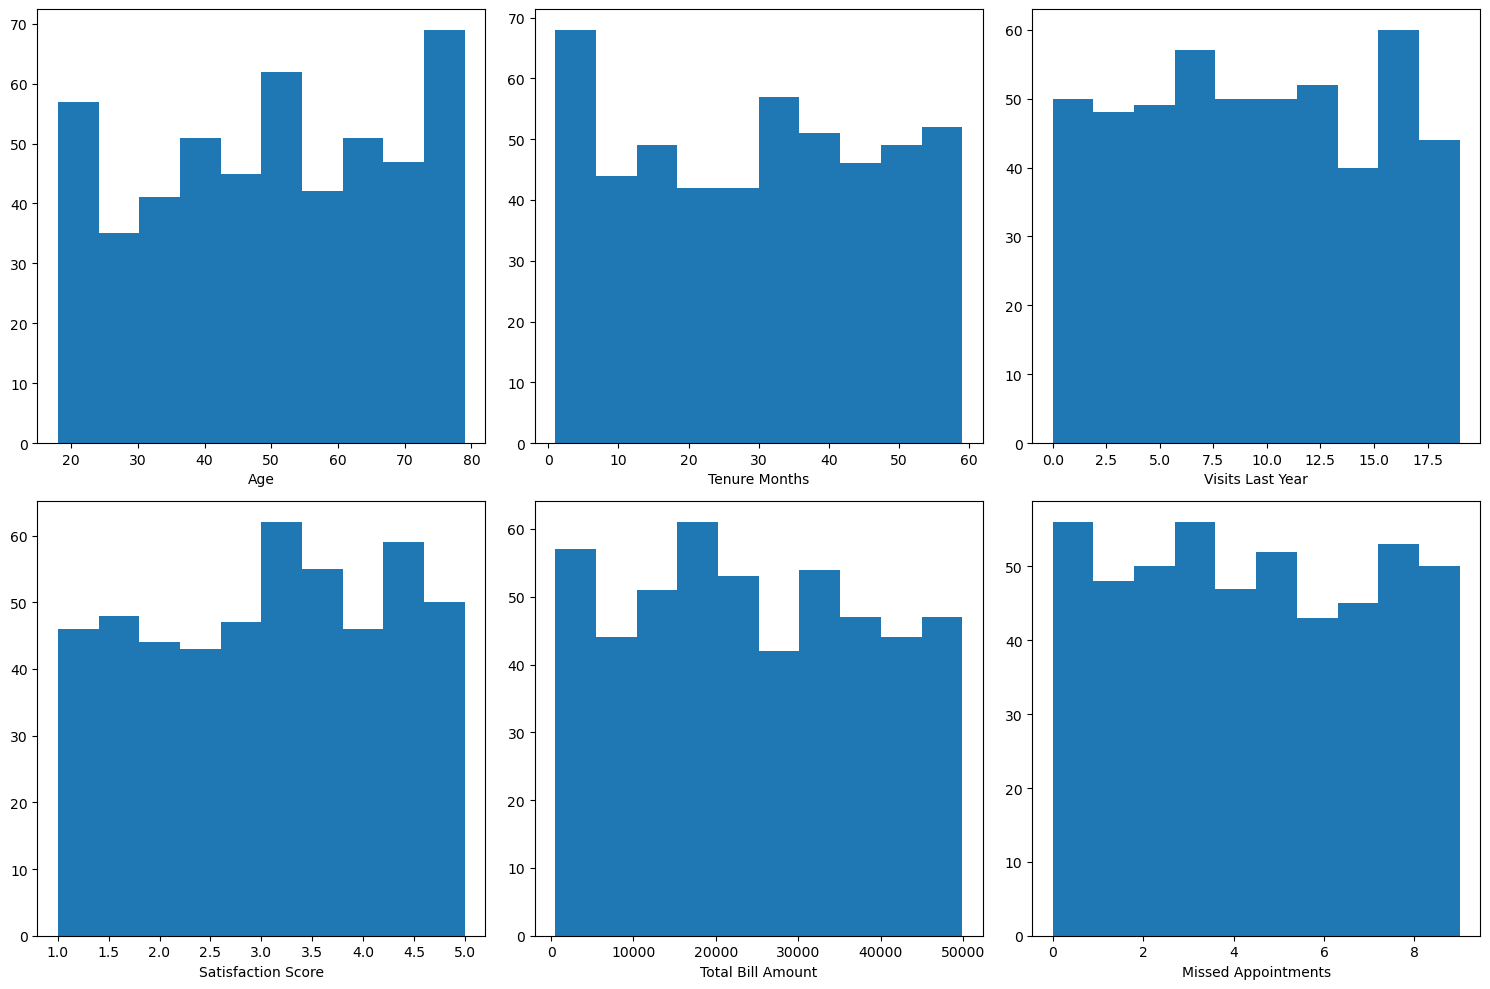

In [12]:
#create histograms for all numeric variables
#assisted by ChatGPT for this step 

X_num = X.select_dtypes(exclude=['object'])
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.reshape(2, 3)

num_vars = len(X_num.columns)  # = 14
b = 0  # column index

for i in range(2):          # rows
    for j in range(3):      # columns
        
        if b >= num_vars:   # stop once we've plotted all variables
            fig.delaxes(axes[i, j])   # remove extra subplot
            continue

        # Plot histogram
        axes[i, j].hist(X_num.iloc[:, b], bins=10)

        # Create pretty label
        var_list = X_num.columns[b].split('_')
        var_list = [word.capitalize() for word in var_list]
        var_print = ' '.join(var_list)

        axes[i, j].set_xlabel(var_print)

        b += 1

plt.tight_layout()
plt.savefig('Histogram_numeric.png')
plt.show()

Index(['Gender', 'Chronic_Disease', 'Insurance_Type'], dtype='object') Index(['Age', 'Tenure_Months', 'Visits_Last_Year', 'Missed_Appointments'], dtype='object')


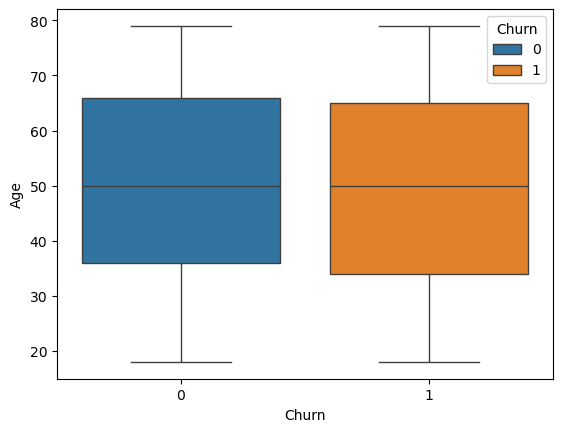

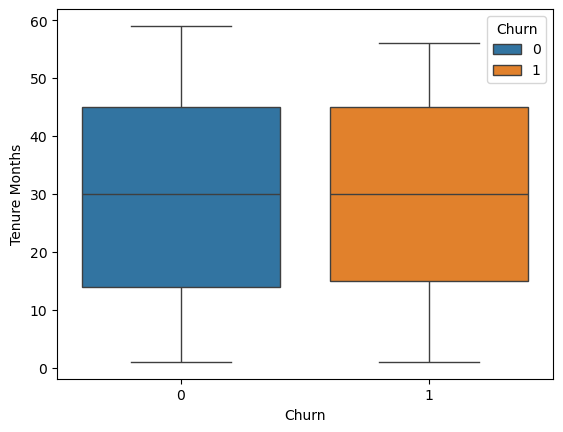

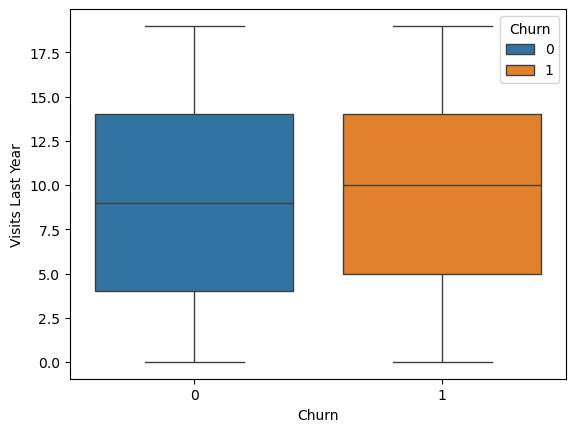

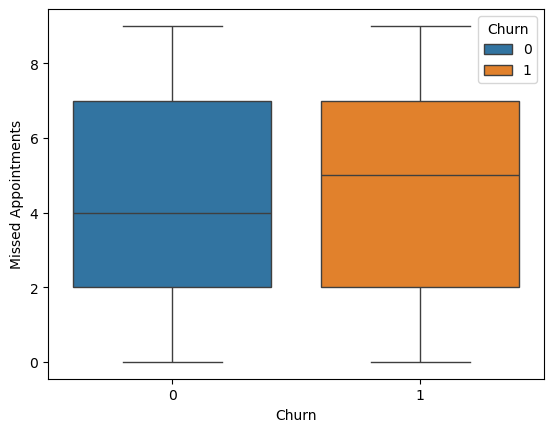

In [13]:
#box plots of numeric variables by churn status 

cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int']).drop(['Churn', 'Patient_ID'], axis = 1).columns
print(cat_cols, num_cols)

df['Insurance_Type'] = df['Insurance_Type'].fillna('None')

for i in num_cols:
    fig = plt.figure()
    sns.boxplot(x = 'Churn', y = df[i], data = df, hue = df['Churn'])
    plt.ylabel(i.replace('_', ' '))

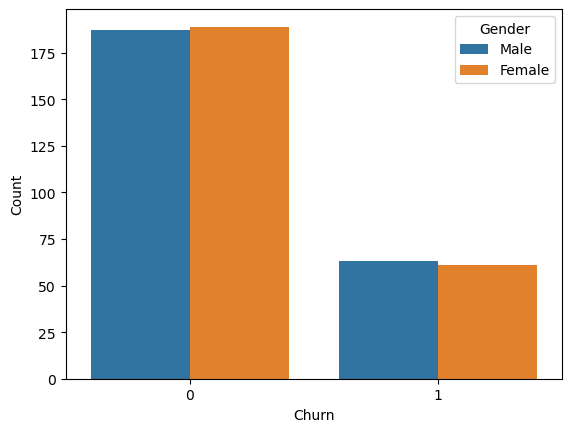

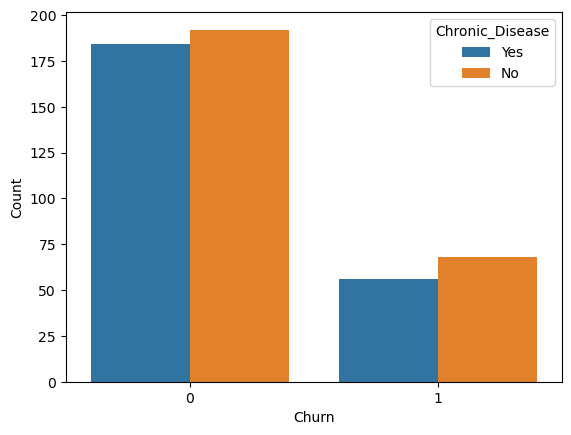

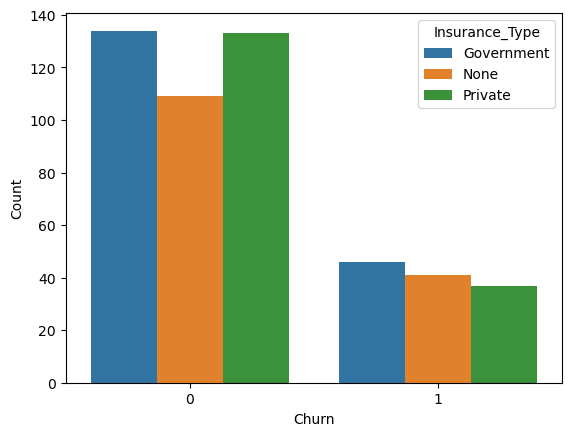

In [14]:
#countplots by churn status for categoric variables
for i in cat_cols:
    fig = plt.figure()
    sns.countplot(x = df['Churn'], data = df, hue = df[i], )
    plt.ylabel('Count')

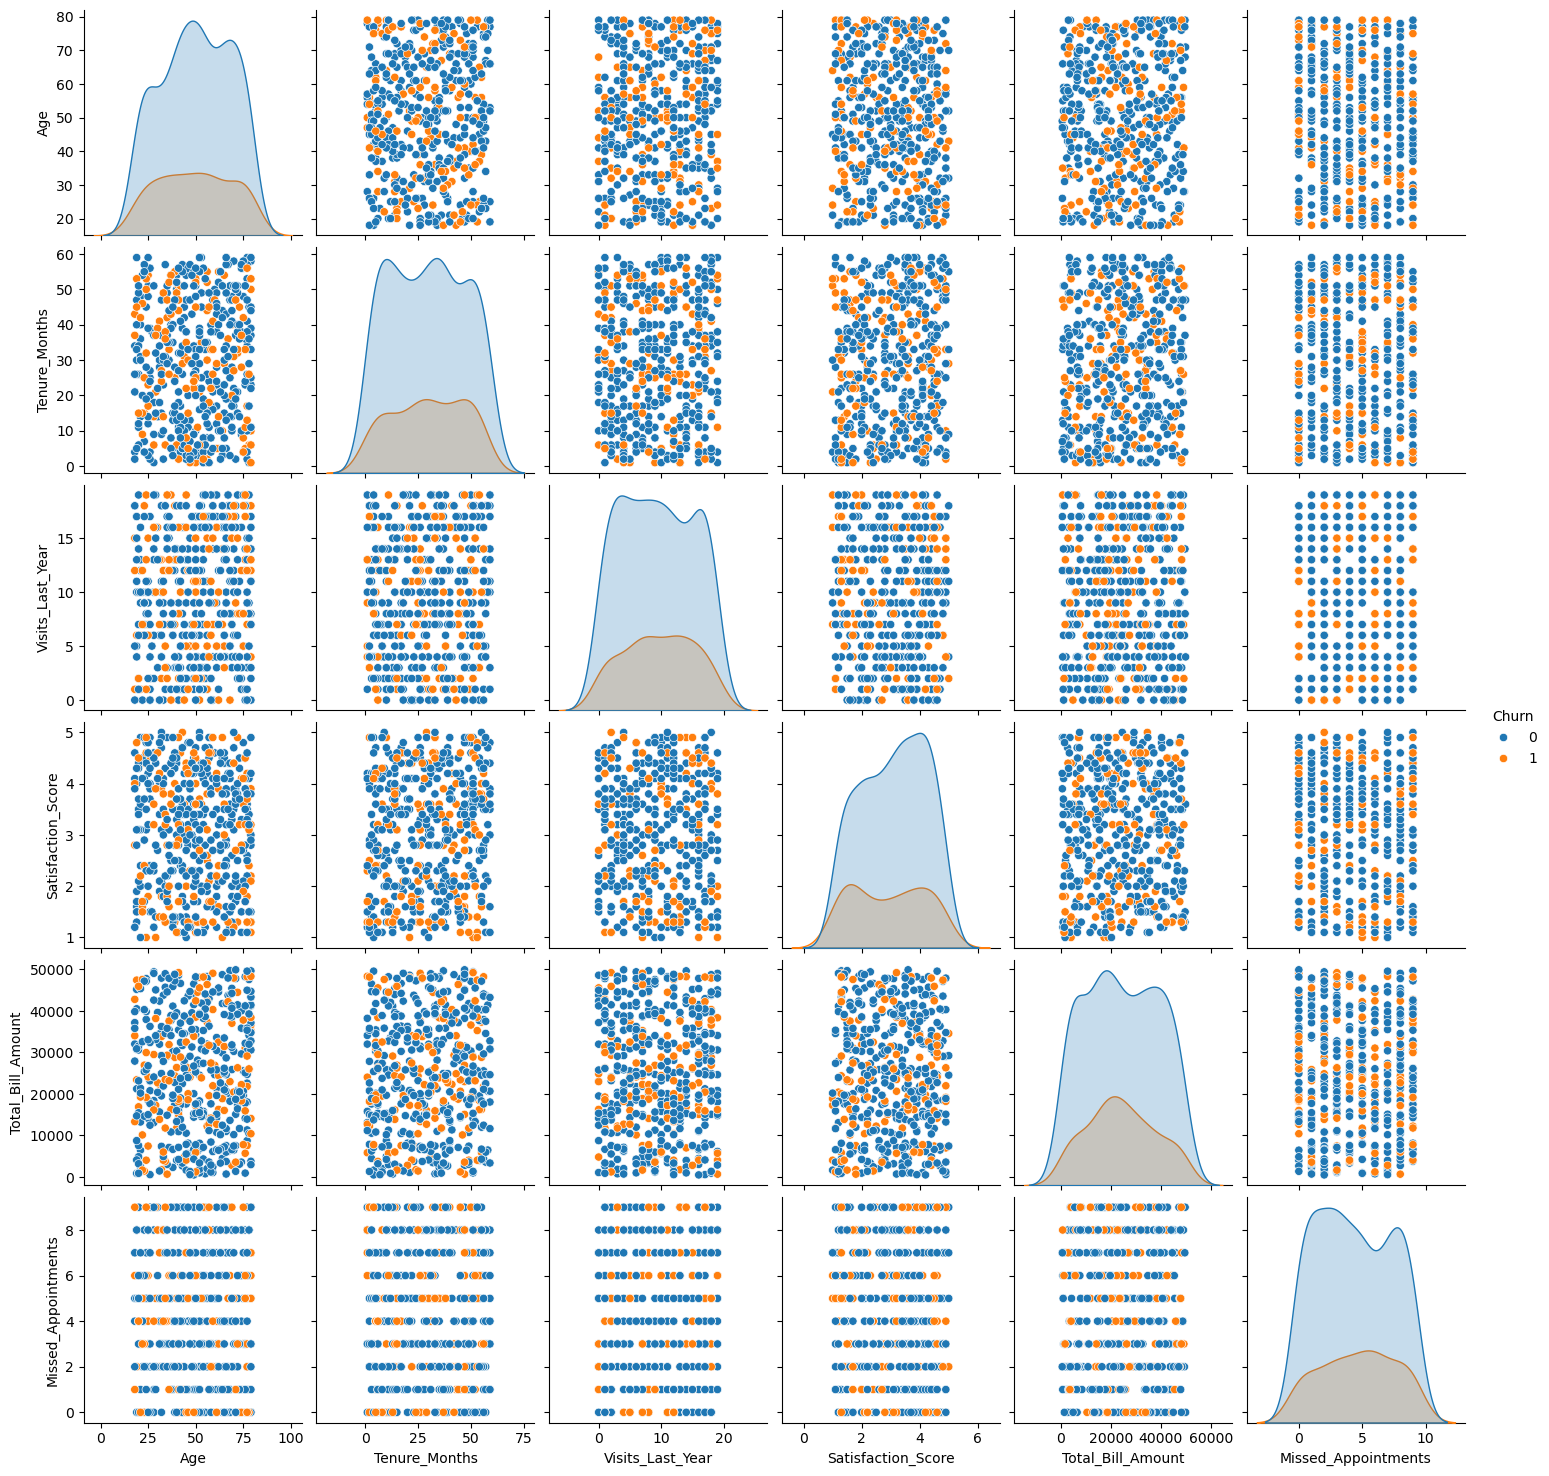

In [15]:
#pairplot to investigate feature correlation
sns.pairplot(df.drop(['Patient_ID'], axis = 1), hue = 'Churn')

In [16]:
#numeric investigation of feature correlation
X.select_dtypes(exclude =['object']).corr()

,Age,Tenure_Months,Visits_Last_Year,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments
Age,1.000000,0.029369,0.079645,-0.055432,0.034746,-0.105451
Tenure_Months,0.029369,1.000000,0.072599,0.084349,0.074024,-0.043867
Visits_Last_Year,0.079645,0.072599,1.000000,-0.013564,-0.004535,0.004248
Satisfaction_Score,-0.055432,0.084349,-0.013564,1.000000,-0.010963,-0.077432
Total_Bill_Amount,0.034746,0.074024,-0.004535,-0.010963,1.000000,-0.002636
Missed_Appointments,-0.105451,-0.043867,0.004248,-0.077432,-0.002636,1.000000


### Modeling and Evaluation

In [17]:
#Checking for na values
for i in train_X.columns: 
   print(i, train_X[i].isna().sum())

Age 0
Gender 0
Tenure_Months 0
Visits_Last_Year 0
Chronic_Disease 0
Insurance_Type 115
Satisfaction_Score 0
Total_Bill_Amount 0
Missed_Appointments 0


In [18]:
# Filling all nas with 'None' to indicate no insurance coverage
train_X['Insurance_Type'] = (
    train_X['Insurance_Type']
    .fillna('None')
)
print(train_X['Insurance_Type'].isna().sum())

0


In [19]:
#creating preprocessor 
cat_col = train_X.select_dtypes(include = 'object').columns.tolist()
num_cols = train_X.columns.difference(cat_cols).tolist()

preprocesser = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output= True
        ), cat_col),
        ('num', 'passthrough', num_cols)
    ]
)

In [20]:
#pipeline creation and 5-fold grid search

pipe = Pipeline ([
    ('preprocessing', preprocesser), 
    ('model', RandomForestClassifier(
    n_estimators= 200, 
    max_features = 2, 
    random_state = 42
  ))
])

params = {
          'model__n_estimators': [200, 100, 50],
        'model__max_features': [2, 3, 4]
}

grid_rf = GridSearchCV(pipe, params, cv = 5).fit(train_X, train_y) 

print(grid_rf.best_estimator_)
print(grid_rf.best_score_)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Chronic_Disease',
                                                   'Insurance_Type']),
                                                 ('num', 'passthrough',
                                                  ['Age', 'Missed_Appointments',
                                                   'Satisfaction_Score',
                                                   'Tenure_Months',
                                                   'Total_Bill_Amount',
                                                   'Visits_Last_Year'])])),
                ('model',
                 RandomForestClassifier(max_features=4, random_state=42))])
0.7550000000000001


In [21]:
# evaluation on test set
y_pred = grid_rf.predict(test_X)
test_acc = accuracy_score(test_y, y_pred)

print(test_acc)

0.74


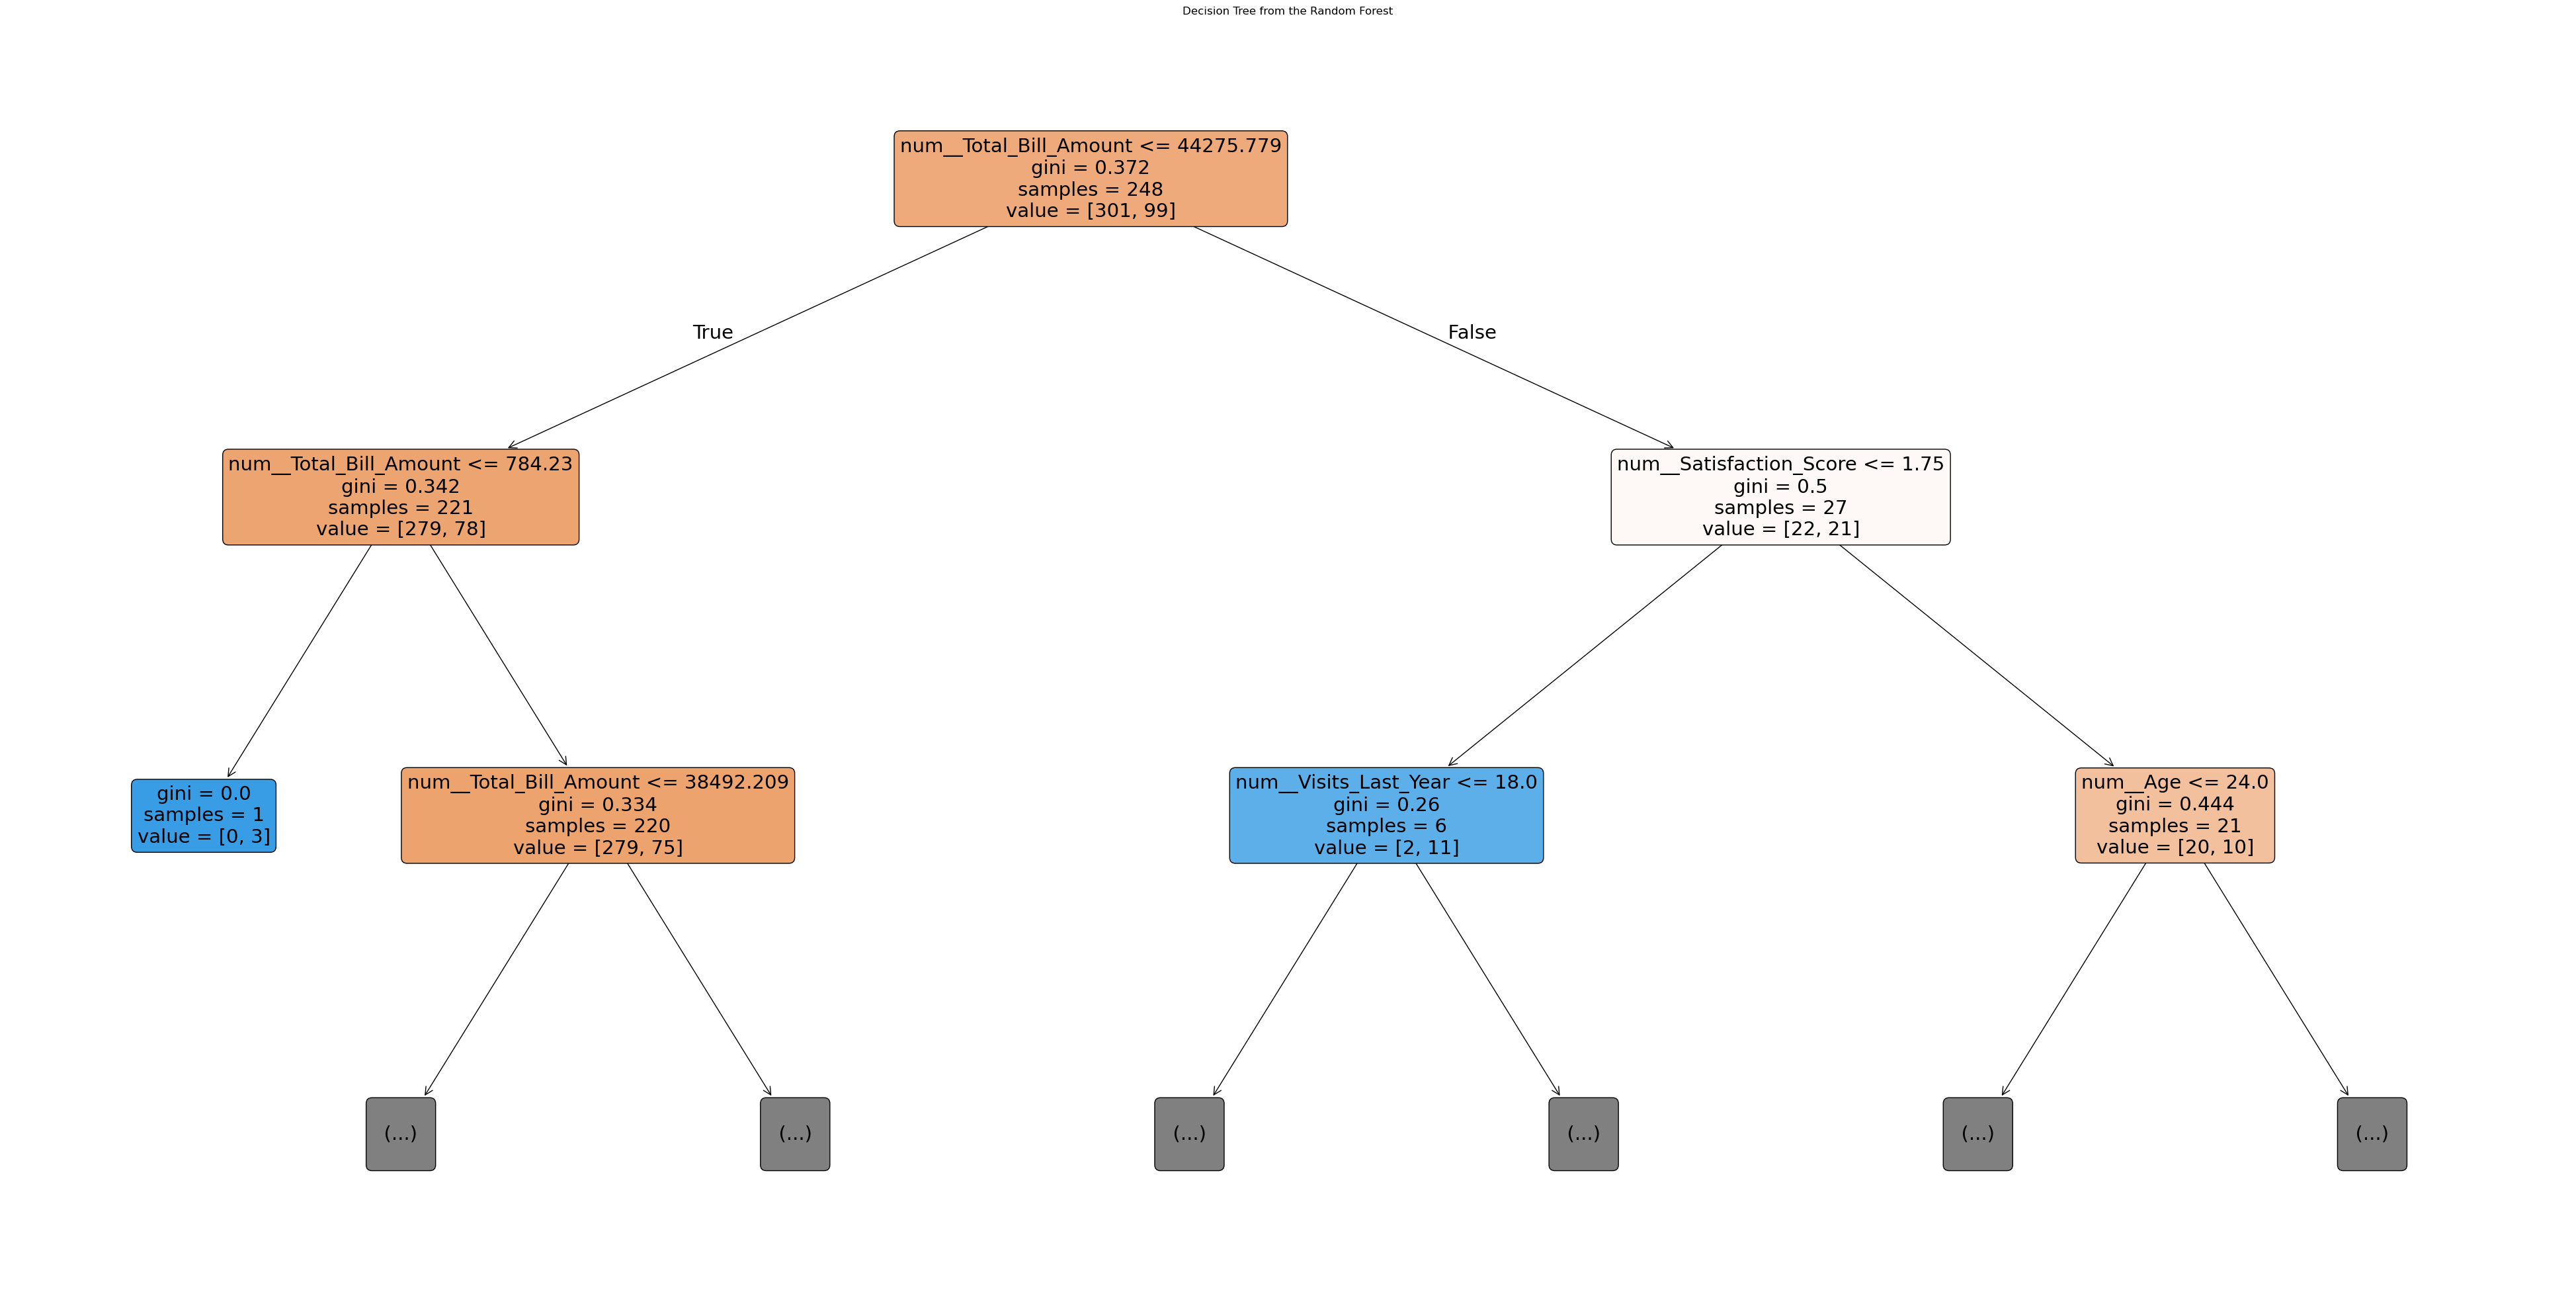

In [22]:
#plot decision tree
#ChatGPT assisted in the code below

# Plot the tree using the plot_tree function from sklearn
tree = grid_rf.best_estimator_.named_steps['model'].estimators_[0]
features = grid_rf.best_estimator_.named_steps['preprocessing'].get_feature_names_out().tolist()
class_names = ['Did Not Churn', 'Churned']


plt.figure(figsize=(50,25))  # Set figure size to make the tree more readable
plot_tree(tree, 
         max_depth = 2,
        feature_names=features,  # Use the feature names from the dataset
      #    class_names=class_names,  # Use class names (species names)
          filled=True,              # Fill nodes with colors for better visualization
          rounded=True)             # Rounded edges for nodes
plt.title("Decision Tree from the Random Forest")
plt.savefig('RandomForest.png')
plt.show()


### Feature Importance Analysis

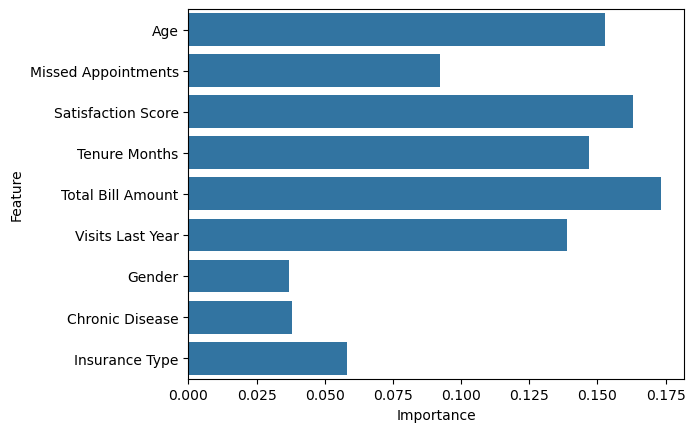

In [23]:
#get feature importances
importances = pd.DataFrame(data = grid_rf.best_estimator_.named_steps['model'].feature_importances_, index = features, columns = ['score'])

importances = importances.transpose()

#sum importances of one-hot-encoded categorical features
importances['Gender'] = sum([importances['cat__Gender_Female'], importances['cat__Gender_Male']])
importances['Chronic Disease'] = sum([importances['cat__Chronic_Disease_No'], importances['cat__Chronic_Disease_Yes']])
importances['Insurance Type'] = sum([importances['cat__Insurance_Type_Government'], importances['cat__Insurance_Type_None'], importances['cat__Insurance_Type_Private']])

#wrangling for plotting
importances = importances.drop(['cat__Gender_Female', 'cat__Gender_Male', 'cat__Chronic_Disease_No', 'cat__Chronic_Disease_Yes', 'cat__Insurance_Type_Government', 'cat__Insurance_Type_None', 'cat__Insurance_Type_Private'], axis = 1)
importances = importances.rename({'num__Age': 'Age', 'num__Missed_Appointments': 'Missed Appointments', 'num__Satisfaction_Score': 'Satisfaction Score', 'num__Tenure_Months': 'Tenure Months', 'num__Total_Bill_Amount':'Total Bill Amount', 'num__Visits_Last_Year': 'Visits Last Year'}, axis = 1)
importances = importances.transpose()
importances.reset_index(inplace = True)
importances.head()

#plot
sns.barplot(y = 'index', x = 'score', data = importances)
plt.ylabel('Feature')
plt.xlabel('Importance')
plt.savefig('Feature_Imp.png')
plt.show()

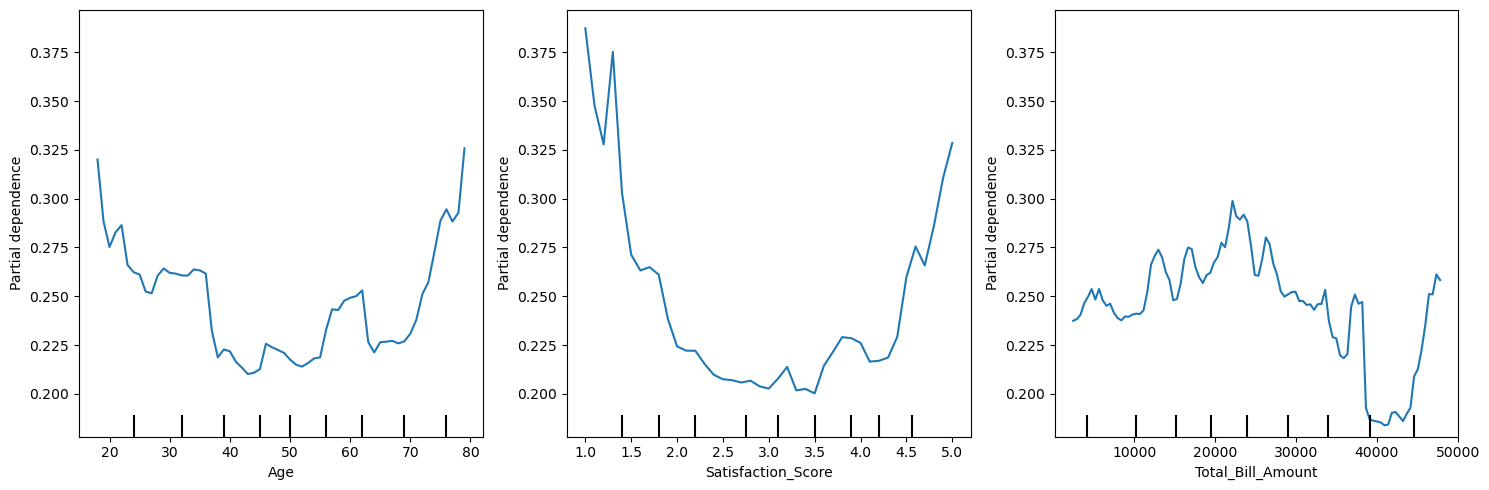

In [24]:
#plot partial dependence plots

features = ['Age', 'Satisfaction_Score', 'Total_Bill_Amount']
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

PartialDependenceDisplay.from_estimator(
    grid_rf.best_estimator_,
    X,
    features=features,
  #  feature_names = ['Age', 'Satisfaction Score', 'Total Bill Amount'],
    ax=ax
)

plt.tight_layout()
plt.savefig('PDD.png')
plt.show()